# Model Development with Python and Software Packages
## Module 5(2) - Ensemble Models
### MBA Admission Prediction
Asst. Prof. Dr. Santitham Prom-on

This notebook predicts whether an MBA application is **Admit** or **Waitlist** using a decision tree, random forest, and gradient boosting classifier.

## Objective and analysis map

The `inputs/MBA.csv` file contains applicant characteristics and an `admission` outcome for a subset of applications. The workflow is:

1. Load and validate the CSV data.
2. Separate labeled applications from rows whose outcome is missing.
3. Explore the target balance and predictor distributions.
4. Prepare numeric and categorical predictors without leaking test-set information.
5. Train a decision tree, random forest, and gradient boosting classifier.
6. Compare the models with classification metrics, confusion matrices, ROC curves, and feature importance.
7. Use the selected model to score the unlabeled applications.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight


class DualFormatTable:
    """Render a DataFrame as HTML in notebooks and LaTeX in PDF exports."""

    def __init__(self, frame: pd.DataFrame) -> None:
        self.frame = frame

    def _repr_html_(self) -> str:
        return self.frame.to_html(index=False)

    def _repr_latex_(self) -> str:
        return self.frame.to_latex(index=False, escape=True)


sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update(
    {
        'figure.dpi': 110,
        'axes.titleweight': 'bold',
        'axes.labelweight': 'bold',
        'figure.constrained_layout.use': True,
    }
)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
RANDOM_STATE = 42

## 1. Load and validate the data

`inputs/MBA.csv` is the single source of truth. The `admission` column is the target. Missing target values are not missing labels to impute: they are applications that will be scored after the supervised models are trained.

In [2]:
DATA_PATH = Path('inputs/MBA.csv')
assert DATA_PATH.exists(), f'Missing data file: {DATA_PATH}'
EXPECTED_COLUMNS = [
    'application_id',
    'gender',
    'international',
    'gpa',
    'major',
    'race',
    'gmat',
    'work_exp',
    'work_industry',
    'admission',
]
raw = pd.read_csv(DATA_PATH)

# Schema, range, and target-contract checks fail loudly if the input changes.
assert raw.shape == (6194, 10), raw.shape
assert raw.columns.tolist() == EXPECTED_COLUMNS
assert raw['application_id'].is_unique
assert raw['application_id'].min() == 1
assert raw['gender'].isin(['Female', 'Male']).all()
assert pd.api.types.is_bool_dtype(raw['international'])
assert raw['major'].isin(['Business', 'Humanities', 'STEM']).all()
assert raw['work_industry'].notna().all()
assert raw['admission'].dropna().isin(['Admit', 'Waitlist']).all()

numeric_columns = ['gpa', 'gmat', 'work_exp']
assert not raw[numeric_columns].isna().any().any()
assert np.isfinite(raw[numeric_columns].to_numpy(dtype=float)).all()
assert raw['gpa'].between(0, 4).all()
assert raw['gmat'].between(200, 800).all()
assert raw['work_exp'].ge(0).all()

labeled_mask = raw['admission'].notna()
assert labeled_mask.sum() == 1000
assert (~labeled_mask).sum() == 5194
assert raw.loc[labeled_mask, 'admission'].value_counts().to_dict() == {
    'Admit': 900,
    'Waitlist': 100,
}

print(f'Loaded {len(raw):,} applications from {DATA_PATH}.')
print(f'Labeled applications: {labeled_mask.sum():,}')
print(f'Unlabeled applications to score: {(~labeled_mask).sum():,}')
display(DualFormatTable(raw.head(8)))

Loaded 6,194 applications from inputs/MBA.csv.
Labeled applications: 1,000
Unlabeled applications to score: 5,194


application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
1,Female,False,3.3000,Business,Asian,620.0000,3.0000,Financial Services,Admit
2,Male,False,3.2800,Humanities,Black,680.0000,5.0000,Investment Management,NaN
3,Female,True,3.3000,Business,NaN,710.0000,5.0000,Technology,Admit
4,Male,False,3.4700,STEM,Black,690.0000,6.0000,Technology,NaN
5,Male,False,3.3500,STEM,Hispanic,590.0000,5.0000,Consulting,NaN
6,Male,False,3.1800,Business,White,610.0000,6.0000,Consulting,NaN
7,Female,False,2.9300,STEM,Other,590.0000,3.0000,Technology,Admit
8,Male,True,3.0200,Business,NaN,630.0000,6.0000,Financial Services,NaN


### Variables and target definition

- `application_id` identifies an application and is excluded from modeling.
- `gpa`, `gmat`, and `work_exp` are numeric predictors.
- `gender`, `international`, `major`, `race`, and `work_industry` are categorical predictors.
- `race` contains missing values and will be imputed inside the preprocessing pipeline.
- The source labels are `Admit` and `Waitlist`; this notebook defines `Admit = 1` and `Waitlist = 0`. Therefore, Waitlist is the not-Admit class for this binary prediction task.

In [3]:
TARGET_MAP = {'Waitlist': 0, 'Admit': 1}
LABEL_ORDER = ['Waitlist', 'Admit']

labeled = raw.loc[labeled_mask].copy()
unlabeled = raw.loc[~labeled_mask].copy()
labeled['admit'] = labeled['admission'].map(TARGET_MAP).astype('int64')

assert labeled['admit'].notna().all()
assert set(labeled['admit'].unique()) == {0, 1}
assert len(labeled) + len(unlabeled) == len(raw)

target_summary = (
    labeled['admission']
    .value_counts()
    .reindex(LABEL_ORDER)
    .rename_axis('admission')
    .reset_index(name='count')
)
target_summary['proportion'] = target_summary['count'] / len(labeled)
display(DualFormatTable(target_summary.round({'proportion': 4})))

admission,count,proportion
Waitlist,100,0.1000
Admit,900,0.9000


feature,count,mean,std,min,max
gpa,"1,000.0000",3.3507,0.1278,2.8900,3.7400
gmat,"1,000.0000",690.8200,40.8411,570.0000,780.0000
work_exp,"1,000.0000",5.0330,1.0054,1.0000,8.0000


column,missing_count
application_id,0
gender,0
international,0
gpa,0
major,0
race,1842
gmat,0
work_exp,0
work_industry,0
admission,5194


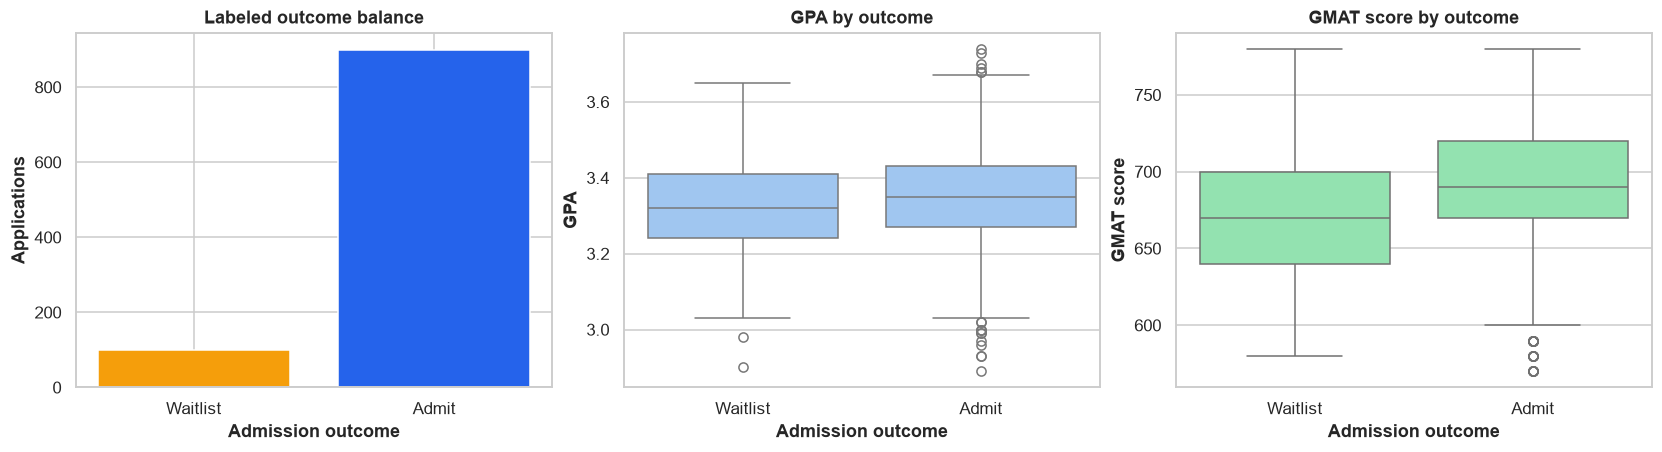

In [4]:
descriptive_summary = (
    labeled[['gpa', 'gmat', 'work_exp']]
    .describe()
    .T[['count', 'mean', 'std', 'min', 'max']]
)
missing_summary = raw.isna().sum().rename('missing_count').to_frame()

display(DualFormatTable(descriptive_summary.reset_index(names='feature').round(4)))
display(DualFormatTable(missing_summary.reset_index(names='column')))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

counts = labeled['admission'].value_counts().reindex(LABEL_ORDER)
axes[0].bar(counts.index, counts.values, color=['#f59e0b', '#2563eb'])
axes[0].set_title('Labeled outcome balance')
axes[0].set_xlabel('Admission outcome')
axes[0].set_ylabel('Applications')

sns.boxplot(data=labeled, x='admission', y='gpa', order=LABEL_ORDER, color='#93c5fd', ax=axes[1])
axes[1].set_title('GPA by outcome')
axes[1].set_xlabel('Admission outcome')
axes[1].set_ylabel('GPA')

sns.boxplot(data=labeled, x='admission', y='gmat', order=LABEL_ORDER, color='#86efac', ax=axes[2])
axes[2].set_title('GMAT score by outcome')
axes[2].set_xlabel('Admission outcome')
axes[2].set_ylabel('GMAT score')

display(fig)
plt.close(fig)

## 2. Prepare the modeling data

Only the 1,000 labeled rows can be used for supervised training and evaluation. A stratified 80/20 split keeps the same Admit/Waitlist ratio in the training and test sets.

Preprocessing is part of every model pipeline:

- Numeric missing values use the training-set median.
- Categorical missing values use the training-set most frequent category.
- Categorical variables are one-hot encoded with unknown categories ignored at prediction time.
- `application_id` is excluded because it is an identifier, not an applicant characteristic.

The labeled outcome is imbalanced (`900 Admit` versus `100 Waitlist`). The decision tree and random forest use balanced class weights. Gradient boosting receives equivalent balanced training sample weights.

In [5]:
FEATURE_COLUMNS = [
    'gender',
    'international',
    'gpa',
    'major',
    'race',
    'gmat',
    'work_exp',
    'work_industry',
]
NUMERIC_FEATURES = ['gpa', 'gmat', 'work_exp']
CATEGORICAL_FEATURES = [
    'gender',
    'international',
    'major',
    'race',
    'work_industry',
]

X = labeled[FEATURE_COLUMNS].copy()
y = labeled['admit'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

assert set(X_train.columns) == set(FEATURE_COLUMNS)
assert len(X_train) == 800 and len(X_test) == 200
assert y_train.value_counts().to_dict() == {1: 720, 0: 80}
assert y_test.value_counts().to_dict() == {1: 180, 0: 20}

preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            Pipeline([('imputer', SimpleImputer(strategy='median'))]),
            NUMERIC_FEATURES,
        ),
        (
            'categorical',
            Pipeline(
                [
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    (
                        'onehot',
                        OneHotEncoder(
                            handle_unknown='ignore',
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

print(f'Training rows: {len(X_train):,}')
print(f'Test rows: {len(X_test):,}')
print(f'Raw predictor columns: {X.shape[1]}')
print(f'Training class counts: {y_train.value_counts().sort_index().to_dict()}')

Training rows: 800
Test rows: 200
Raw predictor columns: 8
Training class counts: {0: 80, 1: 720}


## 3. Model methods

All three classifiers use the same validated predictors and preprocessing so their test-set comparison is fair.

- **Decision tree:** learns a sequence of if/then splits. It is easy to inspect, but unrestricted trees can overfit.
- **Random forest:** fits many randomized decision trees and averages their probabilities. This usually reduces the variance of one tree.
- **Gradient boosting:** fits shallow trees sequentially, with later trees correcting earlier errors. The learning rate and number of trees control the update size and total complexity.

The depth and minimum-leaf settings below limit model complexity. The random seed makes the split and randomized forest reproducible.

In [6]:
MODELS = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=2,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
    ),
}

pipelines = {
    name: Pipeline([('preprocessor', clone(preprocessor)), ('model', model)])
    for name, model in MODELS.items()
}

model_settings = pd.DataFrame(
    {
        'model': list(MODELS),
        'estimator': [type(model).__name__ for model in MODELS.values()],
        'complexity_control': [
            'max_depth=5; min_samples_leaf=10',
            '300 trees; max_depth=8; min_samples_leaf=5',
            '150 trees; learning_rate=0.05; max_depth=2',
        ],
    }
)
display(DualFormatTable(model_settings))

model,estimator,complexity_control
Decision Tree,DecisionTreeClassifier,max_depth=5; min_samples_leaf=10
Random Forest,RandomForestClassifier,300 trees; max_depth=8; min_samples_leaf=5
Gradient Boosting,GradientBoostingClassifier,150 trees; learning_rate=0.05; max_depth=2


## 4. Train the three classifiers

Each pipeline fits its imputer and encoder using `X_train` only. Balanced sample weights are supplied to gradient boosting because that estimator does not expose a `class_weight` parameter.

In [7]:
balanced_train_weights = compute_sample_weight(class_weight='balanced', y=y_train)
fitted_models = {}

for name, pipeline in pipelines.items():
    if name == 'Gradient Boosting':
        pipeline.fit(
            X_train,
            y_train,
            model__sample_weight=balanced_train_weights,
        )
    else:
        pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    print(f'{name}: fitted on {len(X_train):,} labeled applications')

assert set(fitted_models) == set(MODELS)

Decision Tree: fitted on 800 labeled applications


Random Forest: fitted on 800 labeled applications
Gradient Boosting: fitted on 800 labeled applications


## 5. Evaluate the models on held-out labeled applications

The test set is untouched during fitting. The metrics are defined for the positive class `Admit`:

- **Accuracy:** fraction of all test predictions that are correct.
- **Balanced accuracy:** average recall across Admit and Waitlist, useful for an imbalanced target.
- **Precision, recall, and F1 for Admit:** evaluate the quality and coverage of Admit predictions.
- **Waitlist recall:** measures how many not-Admit cases are detected.
- **ROC AUC:** measures ranking quality across probability thresholds.

In [8]:
def admit_probability(estimator: Pipeline, features: pd.DataFrame) -> np.ndarray:
    """Return P(Admit) regardless of classifier class-column order."""

    classifier = estimator.named_steps['model']
    admit_column = int(np.flatnonzero(classifier.classes_ == 1)[0])
    return estimator.predict_proba(features)[:, admit_column]


test_predictions = {}
test_probabilities = {}
evaluation_rows = []

for name, estimator in fitted_models.items():
    predicted = estimator.predict(X_test)
    probability = admit_probability(estimator, X_test)
    test_predictions[name] = predicted
    test_probabilities[name] = probability
    evaluation_rows.append(
        {
            'model': name,
            'accuracy': accuracy_score(y_test, predicted),
            'balanced_accuracy': balanced_accuracy_score(y_test, predicted),
            'precision_admit': precision_score(y_test, predicted, pos_label=1, zero_division=0),
            'recall_admit': recall_score(y_test, predicted, pos_label=1, zero_division=0),
            'f1_admit': f1_score(y_test, predicted, pos_label=1, zero_division=0),
            'recall_waitlist': recall_score(y_test, predicted, pos_label=0, zero_division=0),
            'roc_auc': roc_auc_score(y_test, probability),
        }
    )

metrics = (
    pd.DataFrame(evaluation_rows)
    .sort_values(
        ['balanced_accuracy', 'roc_auc', 'f1_admit'],
        ascending=False,
    )
    .reset_index(drop=True)
)

metric_columns = [column for column in metrics.columns if column != 'model']
assert np.isfinite(metrics[metric_columns].to_numpy(dtype=float)).all()
assert metrics[metric_columns].apply(lambda column: column.between(0, 1).all()).all()

display(DualFormatTable(metrics.round(4)))
best_model_name = metrics.iloc[0]['model']
best_model = fitted_models[best_model_name]
print(f'Selected model: {best_model_name}')
print('Selection criterion: highest balanced accuracy; ROC AUC and F1 break ties.')

model,accuracy,balanced_accuracy,precision_admit,recall_admit,f1_admit,recall_waitlist,roc_auc
Gradient Boosting,0.7300,0.5389,0.9091,0.7778,0.8383,0.3000,0.5325
Decision Tree,0.7450,0.5028,0.9006,0.8056,0.8504,0.2000,0.5362
Random Forest,0.7700,0.4722,0.8941,0.8444,0.8686,0.1000,0.4792


Selected model: Gradient Boosting
Selection criterion: highest balanced accuracy; ROC AUC and F1 break ties.


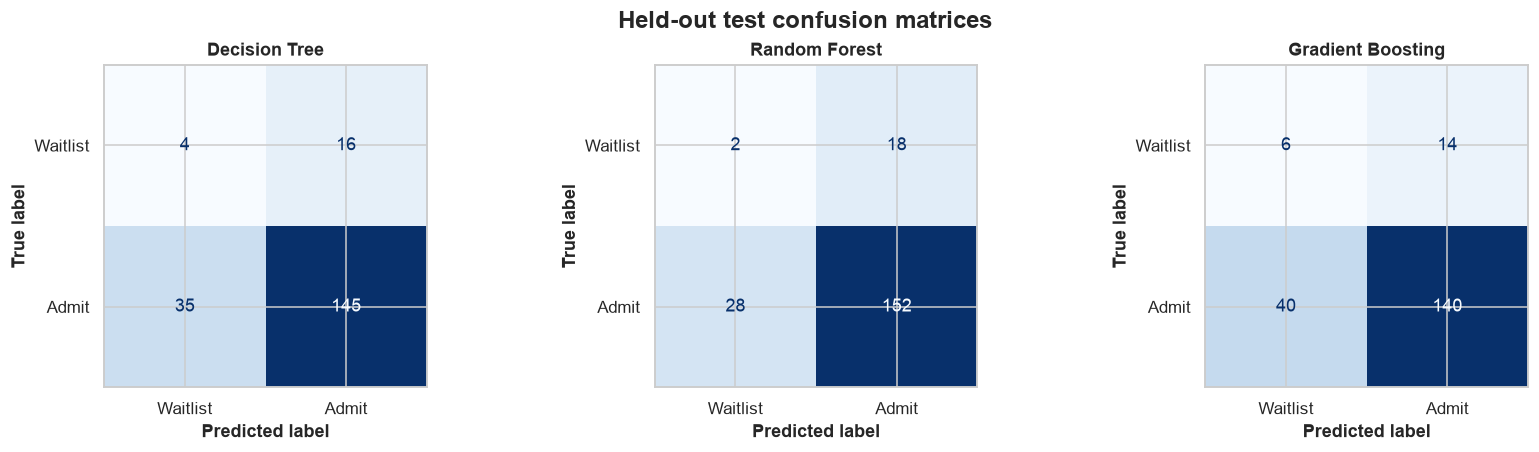

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, name in zip(axes, MODELS):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        test_predictions[name],
        labels=[0, 1],
        display_labels=LABEL_ORDER,
        cmap='Blues',
        colorbar=False,
        ax=ax,
    )
    ax.set_title(name)

fig.suptitle('Held-out test confusion matrices', fontsize=16, fontweight='bold')
display(fig)
plt.close(fig)

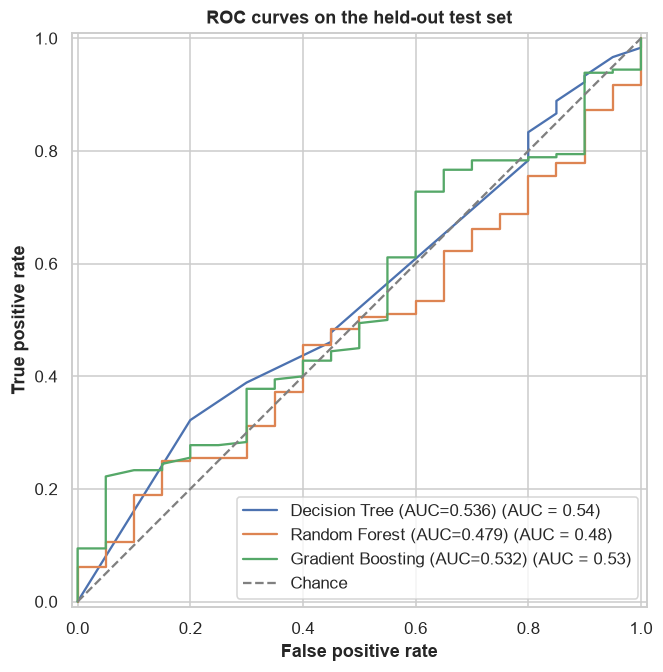

In [10]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
for name in MODELS:
    auc_value = metrics.loc[metrics['model'] == name, 'roc_auc'].iloc[0]
    RocCurveDisplay.from_predictions(
        y_test,
        test_probabilities[name],
        name=f'{name} (AUC={auc_value:.3f})',
        ax=ax,
    )

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance')
ax.set_title('ROC curves on the held-out test set')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.legend(loc='lower right')
display(fig)
plt.close(fig)

### Evaluation interpretation

Balanced accuracy is the selection criterion because a model that predicts Admit for nearly everyone can have high ordinary accuracy while missing most Waitlist cases. The confusion matrices show the actual Admit/Waitlist errors at the default probability threshold of 0.5. ROC AUC evaluates probability ranking independently of that threshold.

These metrics describe predictive association in this dataset. They do not show that any applicant characteristic causes an admission outcome, and performance may change for another applicant population or admissions cycle.

## 6. Compare tree-based feature importance

The values below are impurity-based importance scores for the one-hot encoded predictors. They show which transformed inputs were used most by each fitted model. They are model-specific associations, not causal effects or admissions policy recommendations.

In [11]:
feature_importance_tables = {}

for name, estimator in fitted_models.items():
    fitted_preprocessor = estimator.named_steps['preprocessor']
    classifier = estimator.named_steps['model']
    feature_names = fitted_preprocessor.get_feature_names_out()
    importances = classifier.feature_importances_
    assert len(feature_names) == len(importances)

    importance_table = (
        pd.DataFrame({'feature': feature_names, 'importance': importances})
        .sort_values('importance', ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    feature_importance_tables[name] = importance_table
    print(name)
    display(DualFormatTable(importance_table.round(4)))

Decision Tree


feature,importance
gmat,0.4208
gpa,0.2291
gender_Female,0.0921
race_White,0.0637
international_False,0.0518
major_STEM,0.0383
work_exp,0.0340
major_Humanities,0.0264
international_True,0.0259
major_Business,0.0180


Random Forest


feature,importance
gmat,0.3373
gpa,0.2079
work_exp,0.0734
major_STEM,0.0354
major_Business,0.0286
gender_Female,0.0283
gender_Male,0.0265
work_industry_Technology,0.0240
race_White,0.0233
major_Humanities,0.0228


Gradient Boosting


feature,importance
gmat,0.4610
gpa,0.2165
gender_Female,0.0466
work_exp,0.0462
work_industry_Technology,0.0351
major_STEM,0.0317
work_industry_Investment Management,0.0269
major_Business,0.0239
race_White,0.0218
work_industry_Health Care,0.0152


## 7. Predict the unlabeled applications

The 5,194 rows with a missing `admission` value have no observed outcome for evaluation. Each fitted model produces an `Admit`/`Waitlist` prediction and an estimated probability of Admit. The model selected by held-out balanced accuracy is used as the final prediction.

The complete prediction table is saved as `outputs/MBA_admission_predictions.csv`; it includes every model's prediction and probability so the comparison remains auditable.

In [12]:
X_unlabeled = unlabeled[FEATURE_COLUMNS].copy()
prediction_output = unlabeled[['application_id']].copy()
model_keys = {
    'Decision Tree': 'decision_tree',
    'Random Forest': 'random_forest',
    'Gradient Boosting': 'gradient_boosting',
}

for name, estimator in fitted_models.items():
    key = model_keys[name]
    predicted = estimator.predict(X_unlabeled)
    probability = admit_probability(estimator, X_unlabeled)
    prediction_output[f'{key}_prediction'] = np.where(
        predicted == 1,
        'Admit',
        'Waitlist',
    )
    prediction_output[f'{key}_admit_probability'] = probability

selected_prediction = best_model.predict(X_unlabeled)
selected_probability = admit_probability(best_model, X_unlabeled)
prediction_output['selected_model'] = best_model_name
prediction_output['final_prediction'] = np.where(
    selected_prediction == 1,
    'Admit',
    'Waitlist',
)
prediction_output['final_admit_probability'] = selected_probability

OUTPUT_PATH = Path('outputs/MBA_admission_predictions.csv')
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
prediction_output.to_csv(OUTPUT_PATH, index=False)

probability_columns = [
    column
    for column in prediction_output.columns
    if column.endswith('_admit_probability')
]
assert len(prediction_output) == len(unlabeled) == 5194
assert prediction_output[probability_columns].apply(
    lambda column: column.between(0, 1).all()
).all()
assert OUTPUT_PATH.exists()

display(DualFormatTable(prediction_output.head(10).round(4)))
final_counts = (
    prediction_output['final_prediction']
    .value_counts()
    .reindex(LABEL_ORDER, fill_value=0)
    .rename_axis('final_prediction')
    .reset_index(name='count')
)
display(DualFormatTable(final_counts))
print(f'Saved {len(prediction_output):,} predictions to {OUTPUT_PATH}.')

application_id,decision_tree_prediction,decision_tree_admit_probability,random_forest_prediction,random_forest_admit_probability,gradient_boosting_prediction,gradient_boosting_admit_probability,selected_model,final_prediction,final_admit_probability
2,Admit,0.8302,Admit,0.7095,Admit,0.8195,Gradient Boosting,Admit,0.8195
4,Admit,1.0000,Admit,0.7520,Admit,0.8389,Gradient Boosting,Admit,0.8389
5,Waitlist,0.4906,Waitlist,0.3379,Waitlist,0.3162,Gradient Boosting,Waitlist,0.3162
6,Waitlist,0.4906,Waitlist,0.4130,Admit,0.5078,Gradient Boosting,Admit,0.5078
8,Waitlist,0.4545,Waitlist,0.4112,Waitlist,0.4388,Gradient Boosting,Waitlist,0.4388
9,Waitlist,0.4906,Waitlist,0.4890,Waitlist,0.3580,Gradient Boosting,Waitlist,0.3580
10,Admit,0.6029,Waitlist,0.4284,Admit,0.5104,Gradient Boosting,Admit,0.5104
11,Admit,1.0000,Waitlist,0.4494,Admit,0.6787,Gradient Boosting,Admit,0.6787
12,Admit,1.0000,Waitlist,0.3763,Admit,0.6182,Gradient Boosting,Admit,0.6182
14,Admit,0.6029,Admit,0.7005,Admit,0.5979,Gradient Boosting,Admit,0.5979


final_prediction,count
Waitlist,3318
Admit,1876


Saved 5,194 predictions to outputs/MBA_admission_predictions.csv.


In [13]:
best_metrics = metrics.loc[metrics['model'] == best_model_name].iloc[0]
print('Final result')
print(f'  Selected model: {best_model_name}')
print(f"  Balanced accuracy: {best_metrics['balanced_accuracy']:.4f}")
print(f"  ROC AUC: {best_metrics['roc_auc']:.4f}")
print(f"  Admit F1: {best_metrics['f1_admit']:.4f}")
print(f'  Scored applications: {len(prediction_output):,}')
print(f'  Prediction file: {OUTPUT_PATH}')

Final result
  Selected model: Gradient Boosting
  Balanced accuracy: 0.5389
  ROC AUC: 0.5325
  Admit F1: 0.8383
  Scored applications: 5,194
  Prediction file: outputs/MBA_admission_predictions.csv


## Conclusion

This analysis trains and compares a decision tree, random forest, and gradient boosting classifier for the binary outcome `Admit` versus `Waitlist`. The selected model is the one with the highest balanced accuracy on the untouched stratified test set.

The predictions for rows without observed outcomes are model estimates, not confirmed admissions decisions. They should be reviewed with domain policy, fairness checks, and a future labeled evaluation set before operational use.